In [1]:
import pandas as pd

trades = pd.read_csv("../data/historical_data.csv", nrows=5000)
sentiment = pd.read_csv("../data/fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (5000, 16)
Sentiment shape: (2644, 4)


In [2]:
print(trades['Timestamp'].head())
print("Datatype:", trades['Timestamp'].dtype)

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
Datatype: float64


In [3]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

print(trades['Timestamp'].head())
print("Datatype:", trades['Timestamp'].dtype)
print("Rows:", len(trades))

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ms]
Datatype: datetime64[ms]
Rows: 5000


In [4]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

print(sentiment['date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]


In [5]:
trades['date'] = trades['Timestamp'].dt.date
sentiment['date'] = sentiment['date'].dt.date

print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades date range: 2024-10-27 to 2025-06-15
Sentiment date range: 2018-02-01 to 2025-05-02


In [6]:
data = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged shape:", data.shape)
data.head()

Merged shape: (4737, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed


In [7]:
data['profit'] = data['Closed PnL']

data['is_buy'] = data['Side'].apply(
    lambda x: 1 if str(x).upper() == 'BUY' else 0
)

data['profitable'] = data['profit'] > 0

In [8]:
print("=== Average Profit ===")
print(data.groupby('classification')['profit'].mean())

print("\n=== Trade Count ===")
print(data['classification'].value_counts())

print("\n=== Win Rate ===")
print(data.groupby('classification')['profitable'].mean())

=== Average Profit ===
classification
Fear     135.644924
Greed     87.335448
Name: profit, dtype: float64

=== Trade Count ===
classification
Fear     3905
Greed     832
Name: count, dtype: int64

=== Win Rate ===
classification
Fear     0.365429
Greed    0.140625
Name: profitable, dtype: float64


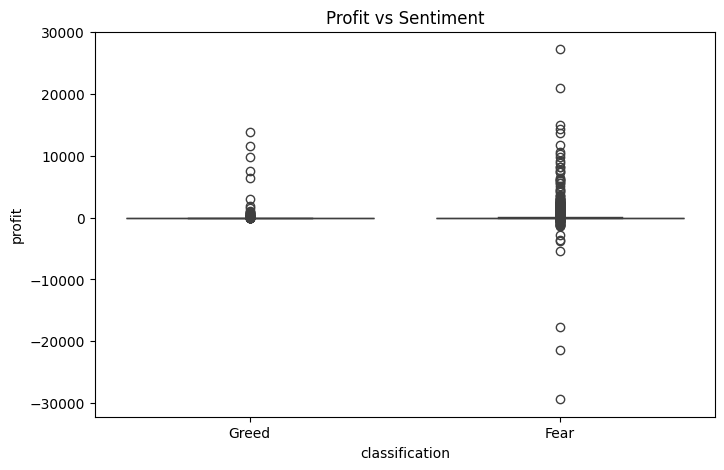

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='profit', data=data)
plt.title("Profit vs Sentiment")
plt.show()

In [13]:
# ================= FEATURE ENGINEERING =================

data['profit'] = data['Closed PnL']

# Convert to numeric
data['Execution Price'] = pd.to_numeric(data['Execution Price'], errors='coerce')
data['Size USD'] = pd.to_numeric(data['Size USD'], errors='coerce')

# Drop nulls
data = data.dropna(subset=['Execution Price', 'Size USD'])

# Features
data['is_buy'] = data['Side'].apply(lambda x: 1 if str(x).upper() == 'BUY' else 0)

# Encode sentiment
data['sentiment_encoded'] = data['classification'].map({
    'Fear': 0,
    'Greed': 1,
    'Neutral': 0.5
})

# Target
data['profitable'] = (data['profit'] > 0).astype(int)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Trade ID,Timestamp,date,timestamp,value,classification,profit,is_buy,profitable,sentiment_encoded
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,0.0,1,0,1.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,0.0,1,0,1.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,0.0,1,0,1.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,0.0,1,0,1.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,0.0,1,0,1.0


In [14]:
# ================= MODEL TRAINING =================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['is_buy', 'Execution Price', 'Size USD', 'sentiment_encoded']

X = data[features]
y = data['profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [15]:
# ================= EVALUATION =================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9926160337552743

Confusion Matrix:
[[624   1]
 [  6 317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       625
           1       1.00      0.98      0.99       323

    accuracy                           0.99       948
   macro avg       0.99      0.99      0.99       948
weighted avg       0.99      0.99      0.99       948



<Axes: title={'center': 'Feature Importance'}>

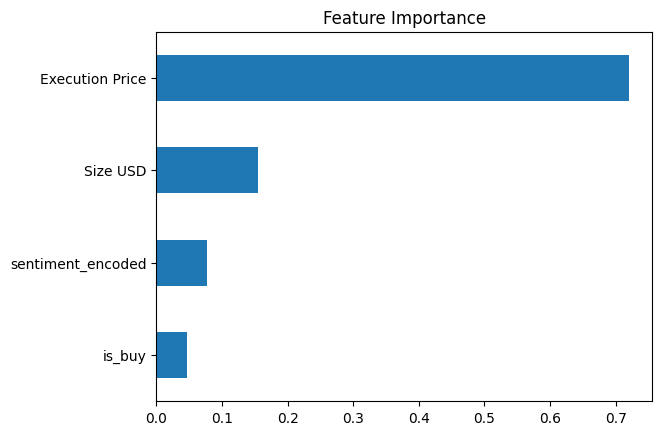

In [16]:
# ================= FEATURE IMPORTANCE =================

import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', title="Feature Importance")

In [17]:
# ================= SMART STRATEGY =================

summary = data.groupby('classification')['profit'].mean()

def suggest_strategy(sentiment):
    if summary[sentiment] > 0:
        return "Profitable zone → Consider trading"
    else:
        return "Loss zone → Avoid trading"

data['strategy'] = data['classification'].apply(suggest_strategy)

data[['classification', 'profit', 'strategy']].head()

,classification,profit,strategy
0,Greed,0.0,Profitable zone → Consider trading
1,Greed,0.0,Profitable zone → Consider trading
2,Greed,0.0,Profitable zone → Consider trading
3,Greed,0.0,Profitable zone → Consider trading
4,Greed,0.0,Profitable zone → Consider trading
